In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [4]:
def my_softmax(z):
    ez=np.exp(z);
    a=ez/np.sum(ez)

    return a
    
    

In [5]:
z = np.array([1., 2., 3., 4.])
a = my_softmax(z)
atf = tf.nn.softmax(z)
print(f"my_softmax(z):         {a}")
print(f"tensorflow softmax(z): {atf}")

my_softmax(z):         [0.0320586  0.08714432 0.23688282 0.64391426]
tensorflow softmax(z): [0.0320586  0.08714432 0.23688282 0.64391426]


In [11]:
def load_data():
    X = np.load("Data/MINST_HANDWRITTEN_DIGITS/X.npy")
    y = np.load("Data/MINST_HANDWRITTEN_DIGITS/y.npy")
    return X, y

In [13]:
X,y=load_data()

In [14]:
print('First Ele of X',X[0])

First Ele of X [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.000000

In [15]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (5000, 400)
The shape of y is: (5000, 1)


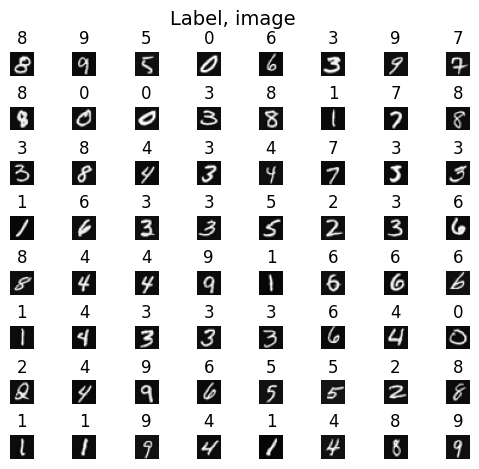

In [21]:
m,n=X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91])

for i,ax in enumerate(axes.flat):
    #select random idx
    r_idx=np.random.randint(m)

    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped=X[r_idx].reshape((20,20)).T

    #Display img
    ax.imshow(X_random_reshaped,cmap='grey')
      # Display the label above the image
    ax.set_title(y[r_idx,0])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)


In [24]:
tf.keras.utils.set_random_seed(123)
model=Sequential([
    tf.keras.Input(shape=(n,)),
    Dense(25,activation='relu',name='L1'),
    Dense(15,activation='relu',name='L2'),
    Dense(10,activation='linear',name='L3') 
])

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ L1 (Dense)                           │ (None, 25)                  │          10,025 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ L2 (Dense)                           │ (None, 15)                  │             390 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ L3 (Dense)                           │ (None, 10)                  │             160 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,575 (41.31 KB)

 Trainable params: 10,575 (41.31 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
W1,b1=model.get_layer('L1').get_weights()
W2,b2=model.get_layer('L2').get_weights()
W3,b3=model.get_layer('L3').get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")


W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


In [29]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)


history=model.fit(X,y,epochs=40)

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 866us/step - loss: 1.5809
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - loss: 0.6575
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - loss: 0.4270
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - loss: 0.3496
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step - loss: 0.3032
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - loss: 0.2707
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - loss: 0.2462
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.2268
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.2105
Epoch 10/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - loss: 0.1962
Epoch 11/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - loss: 0.1835
Epoch 12/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - loss: 0.1720
Epoch 13/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - loss: 0.1614
Epoch 14/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step - loss: 0.1517
Epoch 15/40
157/157 ━━━━━━━━━

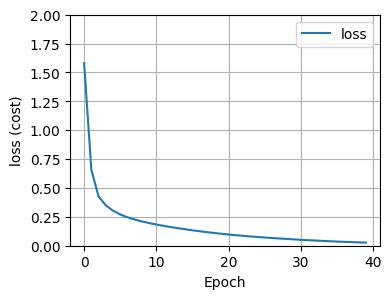

In [30]:
def plot_loss_tf(history):
    fig,ax = plt.subplots(1,1, figsize = (4,3))
    ax.plot(history.history['loss'], label='loss')
    ax.set_ylim([0, 2])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('loss (cost)')
    ax.legend()
    ax.grid(True)
    plt.show()


plot_loss_tf(history)




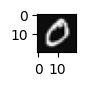

In [35]:
def display_digit(digit_):
    fig,ax=plt.subplots(1,1,figsize=(0.5,0.5))
    digit_reshaped=digit_.reshape((20,20)).T
    ax.imshow(digit_reshaped,cmap='grey')
    plt.show()

zero=X[0]
display_digit(zero)



    

In [37]:
prediction = model.predict(zero.reshape(1,400))  # prediction

print(f" predicting a Two: \n{prediction}")
print(f" Largest Prediction index: {np.argmax(prediction)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
 predicting a Two: 
[[ 13.572584  -18.589476   -4.0968084  -4.8510714 -25.808935   -3.5949488
   -6.4609423  -8.024188   -9.349872   -2.5855105]]
 Largest Prediction index: 0


In [38]:
prediction_p = tf.nn.softmax(prediction)

print(f" predicting a Two. Probability vector: \n{prediction_p}")
print(f"Total of predictions: {np.sum(prediction_p):0.3f}")

 predicting a Two. Probability vector: 
[[9.9999988e-01 1.0769484e-14 2.1197307e-08 9.9702877e-09 7.8853945e-18
  3.5013436e-08 1.9931941e-09 4.1748546e-10 1.1089305e-10 9.6079049e-08]]
Total of predictions: 1.000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━

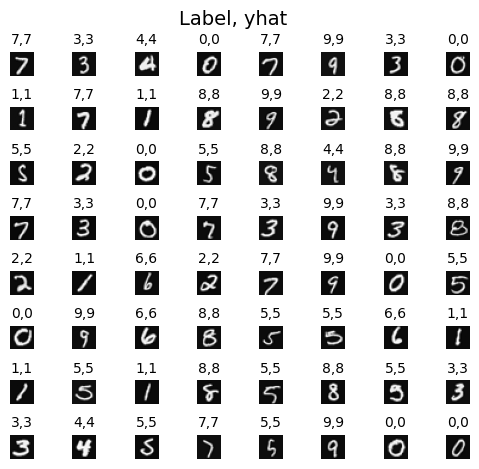

In [47]:
fig,axes=plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]
for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Predict using the Neural Network
    prediction = model.predict(X[random_index].reshape(1,400))
    prediction_p = tf.nn.softmax(prediction)
    yhat = np.argmax(prediction_p)
    
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}",fontsize=10)
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=14)
plt.show()